<a href="https://colab.research.google.com/github/tatahonon/cvNotebooks/blob/main/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_2135/2443795261.py:75: DeprecationWarning: `method='interior-point'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  res = linprog(f, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,


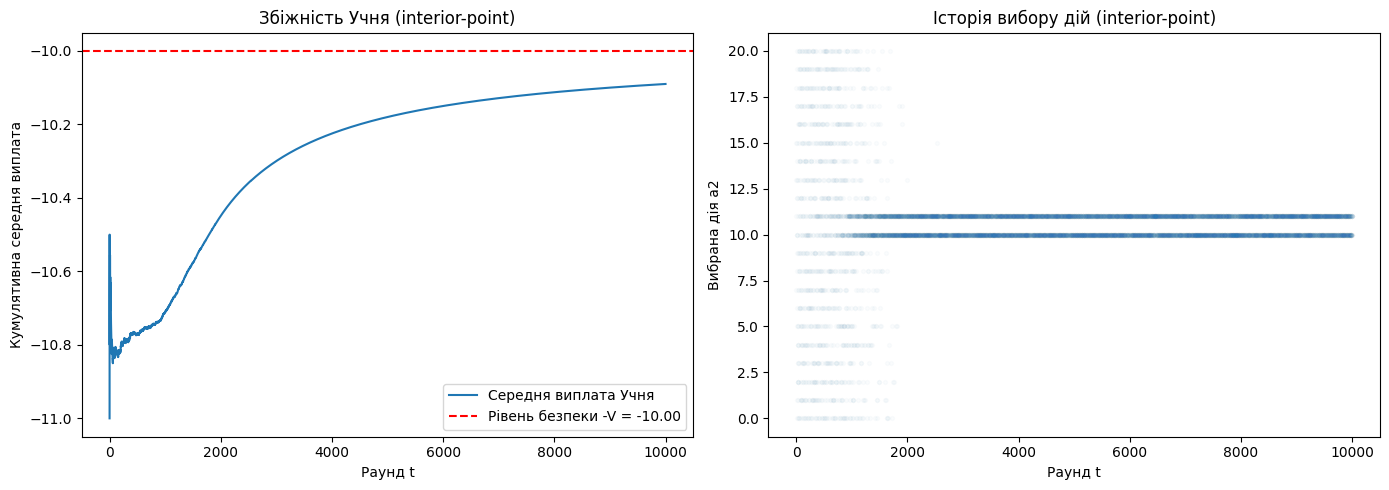

=== Interior-point (змішана стратегія) ===
Рівень безпеки V (аудитора) = 10.0000
Найкраща межа для Учня -V    = -10.0000
Фактична середня виплата     = -10.0899



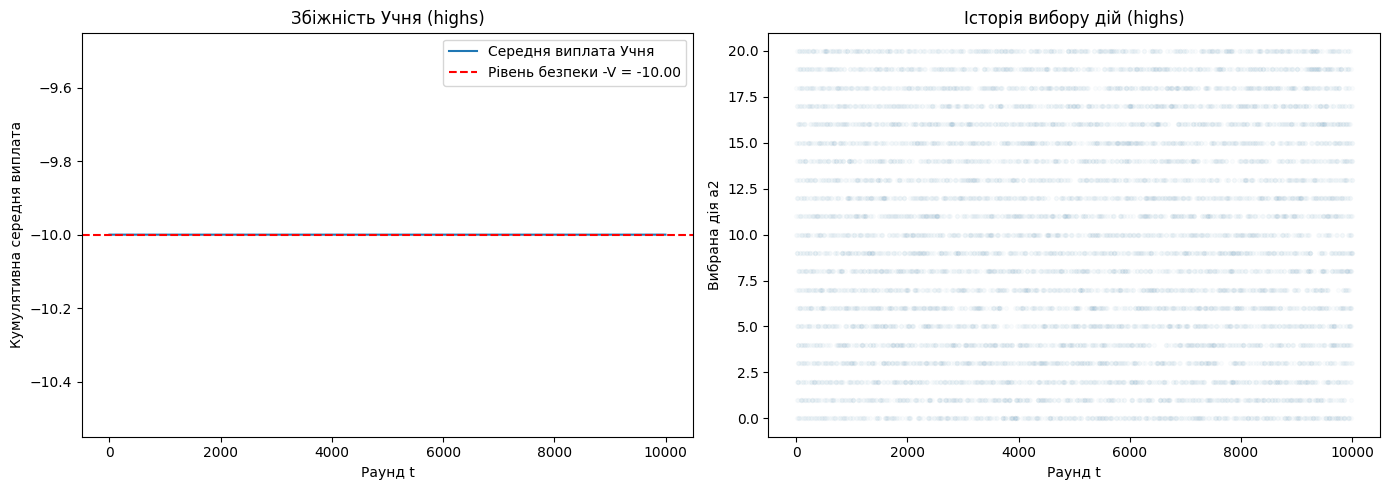

=== Highs / Simplex (чиста стратегія) ===
Рівень безпеки V (аудитора) = 10.0000
Фактична середня виплата     = -10.0000


In [1]:
import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt

K = 20


# ============================================================
# КРОК 1: Матриця виплат
# ============================================================
def build_payoff_matrix(K):
    """
    Матриця U розміром (K+1)x(K+1).
    U[a1, a2] = виплата Гравця 1, коли він вимагає a1, а Гравець 2 — a2.
    """
    U = np.zeros((K + 1, K + 1))
    for a1 in range(K + 1):
        for a2 in range(K + 1):
            if a1 + a2 <= K:
                U[a1, a2] = a1                # вистачає грошей
            else:                             # конфлікт: a1 + a2 > K
                if a1 < a2:
                    U[a1, a2] = a1
                elif a1 > a2:
                    U[a1, a2] = K - a2
                else:                         # a1 == a2
                    U[a1, a2] = K / 2
    return U


# ============================================================
# КРОК 2: Надійний Аудитор (maxmin через лінійне програмування)
# ============================================================
def compute_maxmin_strategy(U, method='interior-point'):
    """
    Знаходимо змішану стратегію x = (x_0,...,x_K) Гравця 1,
    яка гарантує найбільший рівень безпеки V проти будь-якої
    чистої стратегії опонента.

    Вектор змінних: [x_0, ..., x_K, V]  -> всього K+2 змінних.
    linprog мінімізує, тож максимізуємо V як мінімізацію -V.
    """
    n = U.shape[0]                # = K+1

    # Цільова функція: min -V
    f = np.zeros(n + 1)
    f[-1] = -1

    # Обмеження A_ub @ x <= b_ub
    # Для кожної дії опонента a_j:  -sum_i x_i*U[i,j] + V <= 0
    A_ub = np.zeros((n, n + 1))
    for j in range(n):
        A_ub[j, :n] = -U[:, j]
        A_ub[j, -1] = 1
    b_ub = np.zeros(n)

    # Рівність: сума ймовірностей = 1
    A_eq = np.zeros((1, n + 1))
    A_eq[0, :n] = 1
    b_eq = [1]

    # Межі: x_i >= 0, V — вільне
    bounds = [(0, None)] * n + [(None, None)]

    res = linprog(f, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                  bounds=bounds, method=method)

    x = res.x[:n]                 # стратегія
    V = res.x[-1]                 # рівень безпеки
    return x, V


# ============================================================
# КРОК 3: Адаптивний Учень (Q-learning + Softmax)
# ============================================================
class AdaptiveLearner:
    def __init__(self, K, alpha=0.1, tau0=1.0):
        self.K = K
        self.Q = np.zeros(K + 1)      # оцінка цінності кожної дії
        self.alpha = alpha            # крок навчання
        self.tau0 = tau0              # початкова температура
        self.tau = tau0

    def softmax_probs(self):
        z = self.Q / self.tau
        z -= np.max(z)                # стабільний softmax
        e = np.exp(z)
        return e / np.sum(e)

    def choose_action(self):
        return np.random.choice(self.K + 1, p=self.softmax_probs())

    def update(self, a2, reward):
        # Q(a2) <- Q(a2) + alpha * (R - Q(a2))
        self.Q[a2] += self.alpha * (reward - self.Q[a2])

    def decay_temperature(self, t):
        # tau_t = tau0 * exp(-0.001 * t)
        self.tau = self.tau0 * np.exp(-0.001 * t)


# ============================================================
# КРОК 4: Симуляція
# ============================================================
def run_simulation(method='interior-point', T=10000, seed=0):
    np.random.seed(seed)
    U = build_payoff_matrix(K)
    x_auditor, V = compute_maxmin_strategy(U, method=method)
    learner = AdaptiveLearner(K)

    actions = np.zeros(T, dtype=int)
    payoffs = np.zeros(T)             # винагороди учня (R = -u1)

    for t in range(T):
        a1 = np.random.choice(K + 1, p=x_auditor)   # хід аудитора
        a2 = learner.choose_action()                # хід учня
        u1 = U[a1, a2]
        R = -u1                                     # винагорода учня
        learner.update(a2, R)
        learner.decay_temperature(t)
        actions[t] = a2
        payoffs[t] = R

    cum_avg = np.cumsum(payoffs) / np.arange(1, T + 1)
    return cum_avg, actions, V, payoffs


def plot_results(cum_avg, actions, V, title_suffix, filename):
    T = len(actions)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1) Збіжність + 2) рівень безпеки -V
    axes[0].plot(cum_avg, label="Середня виплата Учня")
    axes[0].axhline(-V, color='red', ls='--', label=f"Рівень безпеки -V = {-V:.2f}")
    axes[0].set_xlabel("Раунд t")
    axes[0].set_ylabel("Кумулятивна середня виплата")
    axes[0].set_title(f"Збіжність Учня ({title_suffix})")
    axes[0].legend()

    # 3) Історія вибору дій
    axes[1].scatter(range(T), actions, alpha=0.02, s=8)
    axes[1].set_xlabel("Раунд t")
    axes[1].set_ylabel("Вибрана дія a2")
    axes[1].set_title(f"Історія вибору дій ({title_suffix})")
    axes[1].set_ylim(-1, K + 1)

    plt.tight_layout()
    plt.savefig(filename, dpi=120)
    plt.show()


# ============================================================
# ЗАПУСК
# ============================================================
if __name__ == "__main__":
    # --- Основний прогін: interior-point (змішана стратегія) ---
    cum_avg, actions, V, payoffs = run_simulation('interior-point')
    plot_results(cum_avg, actions, V, "interior-point", "simulation_interior.png")

    print("=== Interior-point (змішана стратегія) ===")
    print(f"Рівень безпеки V (аудитора) = {V:.4f}")
    print(f"Найкраща межа для Учня -V    = {-V:.4f}")
    print(f"Фактична середня виплата     = {cum_avg[-1]:.4f}\n")

    # --- Крок 5.2: default solver 'highs' (чиста стратегія) ---
    cum_avg2, actions2, V2, payoffs2 = run_simulation('highs')
    plot_results(cum_avg2, actions2, V2, "highs", "simulation_highs.png")

    print("=== Highs / Simplex (чиста стратегія) ===")
    print(f"Рівень безпеки V (аудитора) = {V2:.4f}")
    print(f"Фактична середня виплата     = {cum_avg2[-1]:.4f}")